<a href="https://colab.research.google.com/github/ahmmodshihab/ANN-project-Churn/blob/main/cat_v_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [2]:
(train_ds,validation_ds),ds_info=tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]','train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.N5B07H_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [3]:
print(ds_info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [4]:
# generators
'''train_ds=keras.utils.image_dataset_from_directory(
        directory=""
        lables='inferred'
        label_mode='int',
        batch_size=32,
        image_size=(256,256)
)

'''


'train_ds=keras.utils.image_dataset_from_directory(\n        directory=""\n        lables=\'inferred\'\n        label_mode=\'int\',\n        batch_size=32,\n        image_size=(256,256)\n)\n\n'

In [8]:
'''
validation_ds=keras.utils.image_dataset_from_directory(
        directory=""
        lables='inferred'
        label_mode='int',
        batch_size=32,
        image_size=(256,256)
)
'''



'\nvalidation_ds=keras.utils.image_dataset_from_directory(\n        directory=""\n        lables=\'inferred\'\n        label_mode=\'int\',\n        batch_size=32,\n        image_size=(256,256)\n)\n'

In [5]:
# Normalize and Resize
def process(image, label):
    image = tf.image.resize(image, [256, 256])  # Resize images to 256x256
    image = tf.cast(image / 255.0, tf.float32)  # Normalize pixel values
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

# Also, it's good practice to batch and prefetch for performance
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [6]:
from keras.src.ops import BatchNorm
#create CNN model
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',input_shape=(256,256,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 105ms/step - accuracy: 0.5804 - loss: 3.0458 - val_accuracy: 0.6614 - val_loss: 0.6154
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step - accuracy: 0.6989 - loss: 0.5880 - val_accuracy: 0.6831 - val_loss: 0.6120
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.7521 - loss: 0.5206 - val_accuracy: 0.7683 - val_loss: 0.4811
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 90ms/step - accuracy: 0.7947 - loss: 0.4408 - val_accuracy: 0.7304 - val_loss: 0.7893
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 90ms/step - accuracy: 0.8046 - loss: 0.4280 - val_accuracy: 0.7448 - val_loss: 0.5256
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 90ms/step - accuracy: 0.8436 - loss: 0.3583 - val_accuracy: 0.7569 - val_loss: 0.5978
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 92ms/step - accuracy: 0.8875 - loss: 0.2692 - val_accuracy: 0.6595 - val_loss: 0.8492
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 92ms/step - accuracy: 0.9170 - loss: 0.2028 -

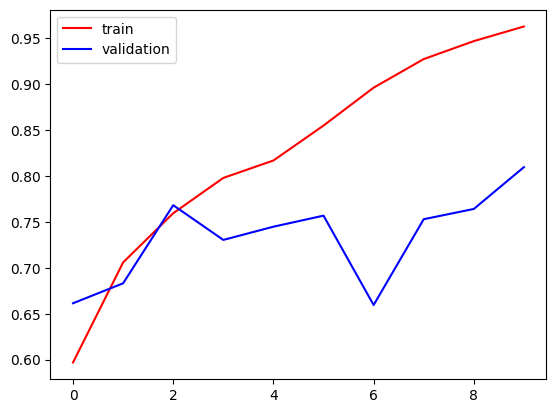

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

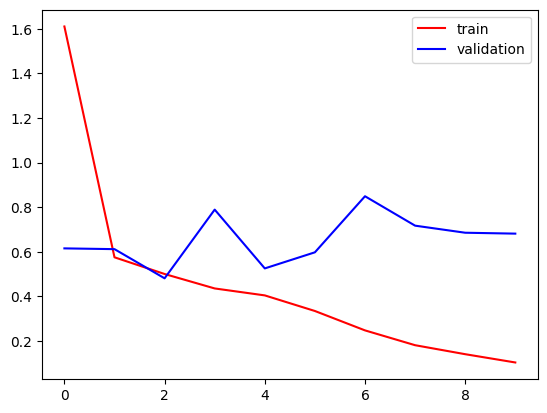

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

### testing model

In [17]:
import cv2

In [40]:
test_img=cv2.imread('/content/dog.jpg.jpg')


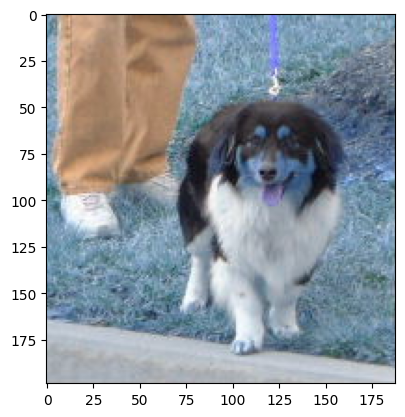

In [41]:
plt.imshow(test_img)

In [20]:
test_img.shape

(199, 188, 3)

In [21]:
test_img=cv2.resize(test_img,(256,256))

In [22]:
test_input=test_img.reshape((1,256,256,3))

In [23]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

In [42]:
# testing cat
test_img2=cv2.imread('/content/cat.jpg.jpg')

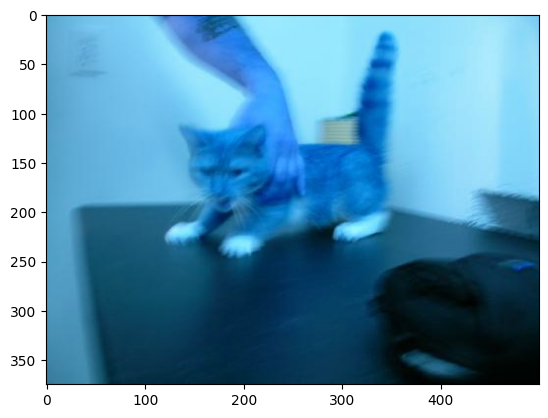

In [43]:
plt.imshow(test_img2)

In [44]:
test_img2=cv2.resize(test_img2,(256,256))

In [47]:
test_input2=test_img2.reshape((1,256,256,3))

In [48]:
model.predict(test_input2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[1.]], dtype=float32)

In [49]:
# another test
test_img3=cv2.imread('/content/cat1.jpg')



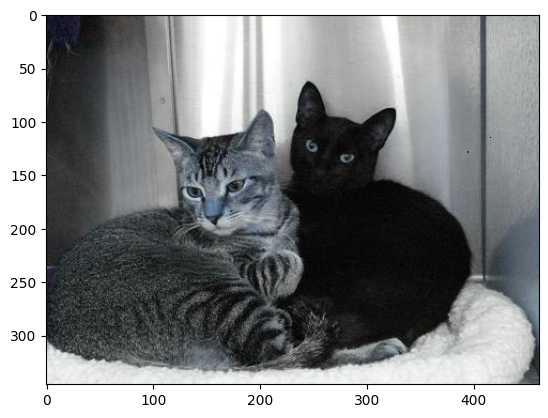

In [50]:
plt.imshow(test_img3)

In [51]:
test_img3=cv2.resize(test_img3,(256,256))

In [52]:
test_input3=test_img3.reshape((1,256,256,3))

In [53]:
model.predict(test_input3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[1.]], dtype=float32)